# Quiz 3.1
## Statistik Deskriptif dengan Numpy
**Mata Kuliah:** Eksplorasi dan Visualisasi Data  
**Sesi:** 4 - Statistik Deskriptif dengan Numpy

## Tentang Dataset

Dataset yang digunakan adalah **BMW Cars Market Dataset (Synthetic)**.

Dataset ini berisi informasi detail mengenai kendaraan BMW yang dirancang untuk eksperimen machine learning, analisis data, dan pemodelan prediktif.

Dataset ini mensimulasikan data pasar kendaraan nyata, mencakup:
- Spesifikasi kendaraan (model, tahun, ukuran mesin, tenaga kuda)
- Informasi harga
- Riwayat kepemilikan
- Metrik lingkungan (konsumsi bahan bakar, emisi CO2)

Dataset mencakup berbagai keluarga model BMW seperti:
- **1 Series, 3 Series, 5 Series, 7 Series**
- **X1, X3, X5, X7** (SUV)
- **Z4** (Roadster)
- **i3, i4, i7** (Model Listrik)

**Jumlah data:** 10.000 baris, 20 kolom

## Import Package

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import shapiro, kstest, anderson

## Import Data

In [ ]:
df = pd.read_csv("bmw_cars_market_dataset_synthetic.csv")
print("Data berhasil diimport!")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

Data berhasil diimport!
Jumlah baris: 10000
Jumlah kolom: 20


## Preview Data

In [ ]:
# Melihat 5 baris pertama
df.head()

,car_id,model,year,engine_size,horsepower,fuel_type,transmission,drivetrain,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,price_usd,doors,seats,body_type,color,owner_count,accident_history,service_history,country_sold
0,1,X5,2016,4.0,272,diesel,automatic,AWD,74655,8.9,196.0,66756,5,5,suv,white,2.0,no,partial,Netherlands
1,2,1 Series,2022,2.6,218,petrol,automatic,FWD,23469,8.4,190.0,26867,3,4,hatchback,black,1.0,no,partial,France
2,3,X1,2012,2.2,240,petrol,automatic,FWD,123273,7.8,174.0,31313,5,5,suv,white,3.0,no,full,Netherlands
3,4,X5,2022,3.8,316,diesel,NaN,AWD,33064,9.4,192.0,81594,5,5,suv,blue,1.0,no,NaN,France
4,5,7 Series,2023,3.1,294,petrol,automatic,RWD,23926,NaN,204.0,104105,4,5,sedan,white,1.0,no,full,Spain


In [ ]:
# Melihat informasi tipe data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   car_id                        10000 non-null  int64  
 1   model                         10000 non-null  str    
 2   year                          10000 non-null  int64  
 3   engine_size                   9757 non-null   float64
 4   horsepower                    10000 non-null  int64  
 5   fuel_type                     10000 non-null  str    
 6   transmission                  9785 non-null   str    
 7   drivetrain                    10000 non-null  str    
 8   mileage_km                    10000 non-null  int64  
 9   fuel_consumption_l_per_100km  9754 non-null   float64
 10  co2_emissions_g_km            9775 non-null   float64
 11  price_usd                     10000 non-null  int64  
 12  doors                         10000 non-null  int64  
 13  seats        

In [ ]:
# Melihat nama kolom
print(df.columns.tolist())

['car_id', 'model', 'year', 'engine_size', 'horsepower', 'fuel_type', 'transmission', 'drivetrain', 'mileage_km', 'fuel_consumption_l_per_100km', 'co2_emissions_g_km', 'price_usd', 'doors', 'seats', 'body_type', 'color', 'owner_count', 'accident_history', 'service_history', 'country_sold']


## Analisis Deskriptif

Statistik deskriptif adalah teknik analisis yang digunakan untuk meringkas dan mendeskripsikan karakteristik data numerik. Metrik yang umum digunakan:

- **Mean (Rata-rata):** Nilai rata-rata dari sekumpulan data
- **Median:** Nilai tengah dari data yang telah diurutkan
- **Mode:** Nilai yang paling sering muncul dalam data
- **Variance (Varians):** Ukuran dari seberapa jauh data tersebar dari mean
- **Standard Deviation (Standar Deviasi):** Akar kuadrat dari varians

In [ ]:
# Ambil kolom numerik yang akan dianalisis
price = np.array(df['price_usd'])
horsepower = np.array(df['horsepower'])
mileage = np.array(df['mileage_km'])

### Statistik Deskriptif: Harga Mobil (price_usd)

In [ ]:
mean = np.mean(price)
median = np.median(price)
mode = stats.mode(price)
variance = np.var(price)
std_dev = np.std(price)

print(f'Mean: {mean:.2f}')
print(f'Median: {median:.2f}')
print(f'Mode: {mode.mode}')
print(f'Variance: {variance:.2f}')
print(f'Standard Deviation: {std_dev:.2f}')

Mean: 50861.40
Median: 44324.00
Mode: 2640
Variance: 969102409.69
Standard Deviation: 31130.41


### Statistik Deskriptif: Tenaga Kuda (horsepower)

In [ ]:
mean_hp = np.mean(horsepower)
median_hp = np.median(horsepower)
mode_hp = stats.mode(horsepower)
variance_hp = np.var(horsepower)
std_dev_hp = np.std(horsepower)

print(f'Mean: {mean_hp:.2f}')
print(f'Median: {median_hp:.2f}')
print(f'Mode: {mode_hp.mode}')
print(f'Variance: {variance_hp:.2f}')
print(f'Standard Deviation: {std_dev_hp:.2f}')

Mean: 269.95
Median: 260.00
Mode: 239
Variance: 6509.81
Standard Deviation: 80.68


### Ringkasan Statistik Semua Kolom Numerik

In [ ]:
# describe() memberikan ringkasan statistik secara otomatis
df.describe()

,car_id,year,engine_size,horsepower,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,price_usd,doors,seats,owner_count
count,10000.00000,10000.000000,9757.000000,10000.000000,10000.000000,9754.000000,9775.000000,10000.000000,10000.000000,10000.000000,9745.000000
mean,5000.50000,2016.381700,2.484555,269.948600,112364.794000,6.568987,144.105678,50861.398800,4.319900,4.725600,1.943048
std,2886.89568,5.442478,1.201003,80.687398,86335.775989,3.021995,67.019864,31131.966363,0.774741,0.691052,1.378248
min,1.00000,2005.000000,0.000000,120.000000,0.000000,0.000000,0.000000,2640.000000,2.000000,2.000000,0.000000
25%,2500.75000,2012.000000,2.000000,211.000000,39924.000000,5.400000,118.000000,29330.250000,4.000000,5.000000,1.000000
50%,5000.50000,2017.000000,2.600000,260.000000,94483.000000,7.200000,157.000000,44324.000000,4.000000,5.000000,2.000000
75%,7500.25000,2021.000000,3.300000,317.000000,171752.750000,8.700000,191.000000,63835.500000,5.000000,5.000000,3.000000
max,10000.00000,2024.000000,5.000000,700.000000,300000.000000,12.900000,297.000000,225487.000000,5.000000,5.000000,5.000000


## Visualisasi Data

Visualisasi data membantu kita memahami pola dan distribusi dalam dataset secara lebih intuitif.

### Visualisasi dengan Matplotlib

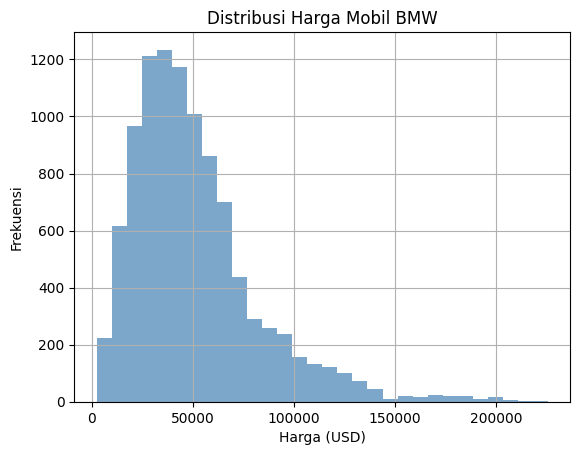

In [ ]:
# Histogram Harga Mobil
plt.hist(price, bins=30, color='steelblue', alpha=0.7)
plt.title('Distribusi Harga Mobil BMW')
plt.xlabel('Harga (USD)')
plt.ylabel('Frekuensi')
plt.grid()
plt.show()

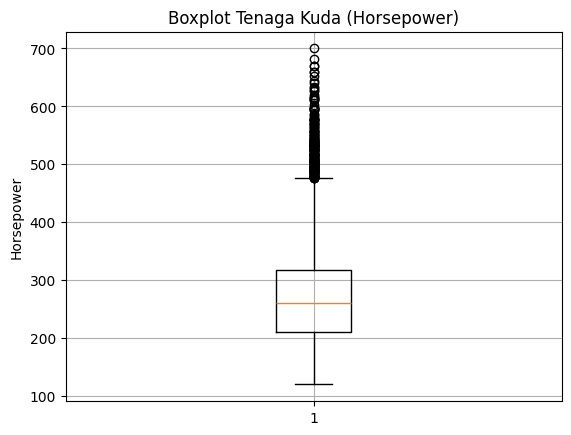

In [ ]:
# Boxplot Horsepower
plt.boxplot(horsepower)
plt.title('Boxplot Tenaga Kuda (Horsepower)')
plt.ylabel('Horsepower')
plt.grid()
plt.show()

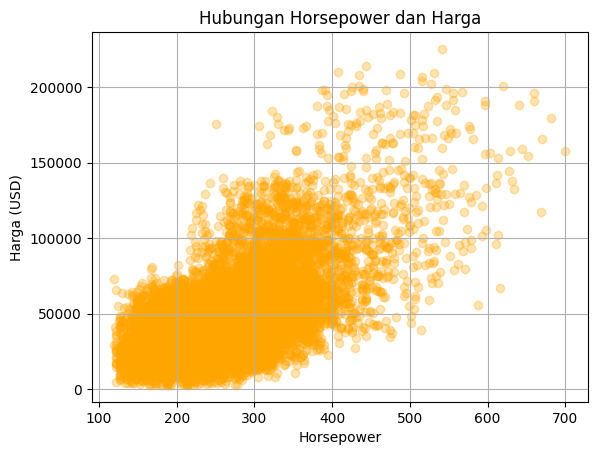

In [ ]:
# Scatter Plot: Horsepower vs Harga
plt.scatter(df['horsepower'], df['price_usd'], alpha=0.3, color='orange')
plt.title('Hubungan Horsepower dan Harga')
plt.xlabel('Horsepower')
plt.ylabel('Harga (USD)')
plt.grid()
plt.show()

### Visualisasi dengan Seaborn

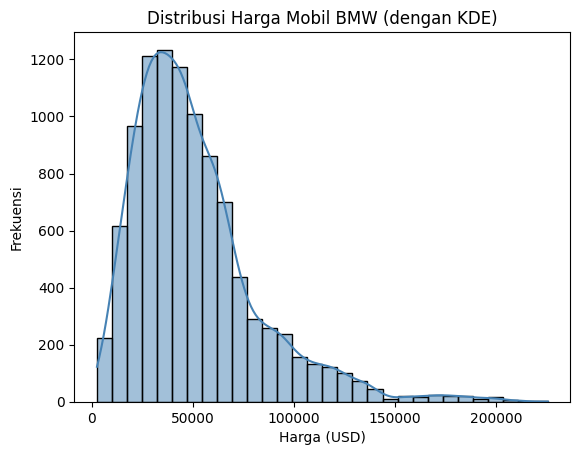

In [ ]:
# Distribusi Harga dengan Seaborn
sns.histplot(df['price_usd'], bins=30, kde=True, color='steelblue')
plt.title('Distribusi Harga Mobil BMW (dengan KDE)')
plt.xlabel('Harga (USD)')
plt.ylabel('Frekuensi')
plt.show()

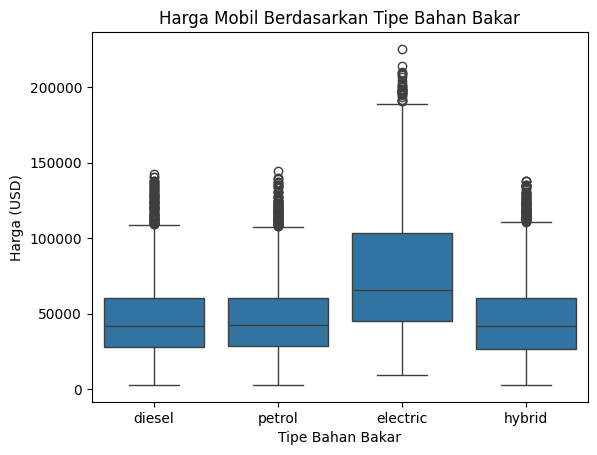

In [ ]:
# Boxplot per Tipe Bahan Bakar
sns.boxplot(data=df, x='fuel_type', y='price_usd')
plt.title('Harga Mobil Berdasarkan Tipe Bahan Bakar')
plt.xlabel('Tipe Bahan Bakar')
plt.ylabel('Harga (USD)')
plt.show()

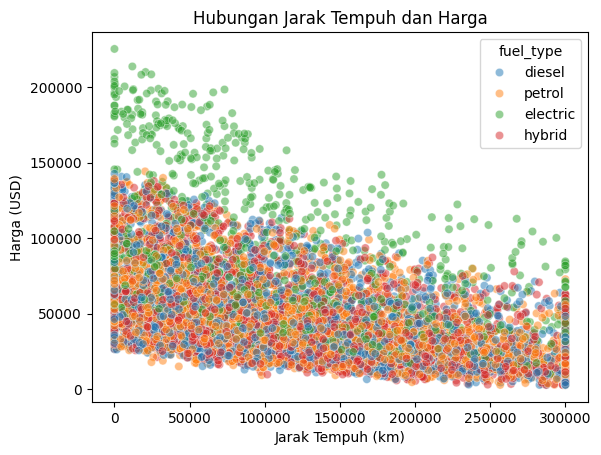

In [ ]:
# Scatter Plot: Mileage vs Harga
sns.scatterplot(data=df, x='mileage_km', y='price_usd', hue='fuel_type', alpha=0.5)
plt.title('Hubungan Jarak Tempuh dan Harga')
plt.xlabel('Jarak Tempuh (km)')
plt.ylabel('Harga (USD)')
plt.show()

## Cek Distribusi Data

Kita akan mengecek distribusi data menggunakan beberapa metode:
1. **Histogram** - melihat bentuk distribusi secara visual
2. **Boxplot** - melihat median, kuartil, dan outlier
3. **QQ-Plot** - membandingkan distribusi data dengan distribusi normal
4. **Uji Statistik** - Shapiro-Wilk, Kolmogorov-Smirnov, Anderson-Darling

### Histogram - Distribusi Harga

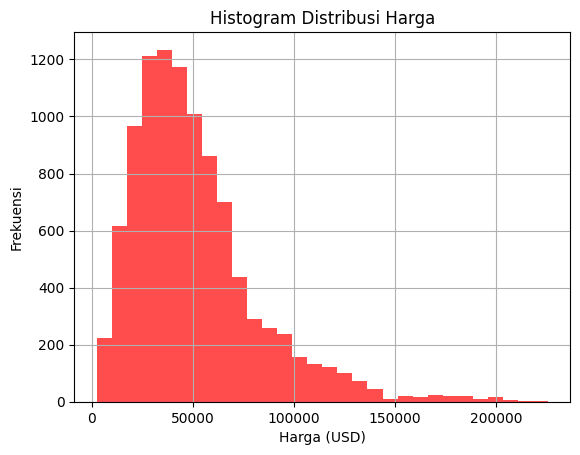

In [ ]:
plt.hist(price, bins=30, color='red', alpha=0.7)
plt.title('Histogram Distribusi Harga')
plt.xlabel('Harga (USD)')
plt.ylabel('Frekuensi')
plt.grid()
plt.show()

### Boxplot - Distribusi Harga

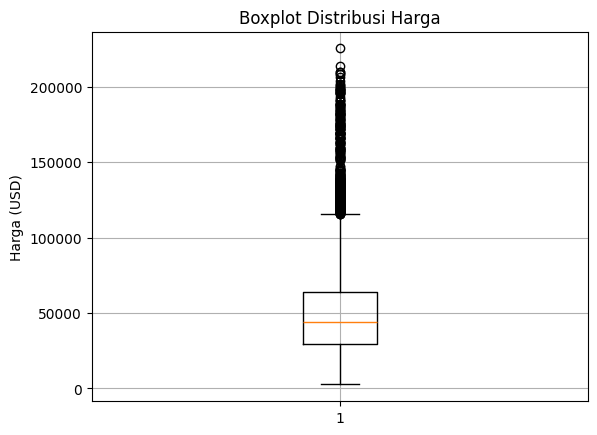

Interpretasi Boxplot:
- Median (Q2): 44324.00
- Q1 (25%): 29330.25
- Q3 (75%): 63835.50


In [ ]:
plt.boxplot(price)
plt.title('Boxplot Distribusi Harga')
plt.ylabel('Harga (USD)')
plt.grid()
plt.show()

print("Interpretasi Boxplot:")
print(f"- Median (Q2): {np.median(price):.2f}")
print(f"- Q1 (25%): {np.percentile(price, 25):.2f}")
print(f"- Q3 (75%): {np.percentile(price, 75):.2f}")

### QQ-Plot - Distribusi Harga

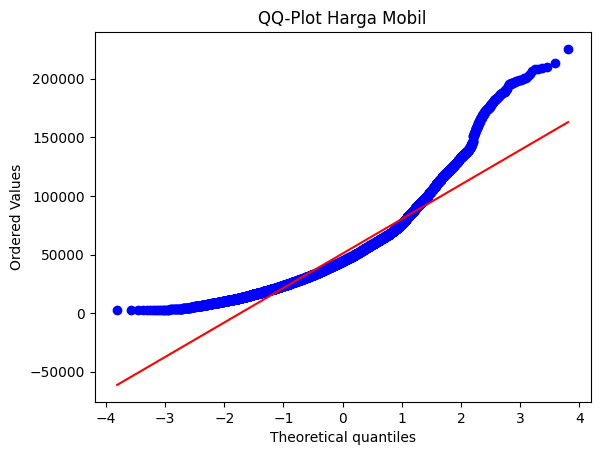

Interpretasi QQ-Plot:
- Jika titik-titik mengikuti garis lurus, data kemungkinan berdistribusi normal
- Jika titik-titik menyimpang, data mungkin tidak berdistribusi normal


In [ ]:
# QQ-plot untuk mengecek apakah data mendekati distribusi normal
stats.probplot(price, dist="norm", plot=plt)
plt.title('QQ-Plot Harga Mobil')
plt.show()

print("Interpretasi QQ-Plot:")
print("- Jika titik-titik mengikuti garis lurus, data kemungkinan berdistribusi normal")
print("- Jika titik-titik menyimpang, data mungkin tidak berdistribusi normal")

### Uji Statistik: Shapiro-Wilk

In [ ]:
# Uji Shapiro-Wilk (gunakan sampel karena data besar)
sample_price = np.random.choice(price, size=5000, replace=False)

stat, p_value = shapiro(sample_price)
print(f'Statistik Uji: {stat:.4f}, p-value: {p_value:.4f}')

if p_value > 0.05:
    print("Data kemungkinan berdistribusi normal")
else:
    print("Data tidak berdistribusi normal")

Statistik Uji: 0.8870, p-value: 0.0000
Data tidak berdistribusi normal


### Uji Statistik: Kolmogorov-Smirnov

In [ ]:
# Uji Kolmogorov-Smirnov
stat, p_value = kstest(price, 'norm')
print(f'Statistik Uji: {stat:.4f}, p-value: {p_value:.4f}')

if p_value > 0.05:
    print("Data kemungkinan berdistribusi normal")
else:
    print("Data tidak berdistribusi normal")

Statistik Uji: 1.0000, p-value: 0.0000
Data tidak berdistribusi normal


### Uji Statistik: Anderson-Darling

In [ ]:
# Uji Anderson-Darling
result = anderson(price)
print(f'Statistik Uji: {result.statistic:.4f}')
for i in range(len(result.critical_values)):
    sl, cv = result.significance_level[i], result.critical_values[i]
    if result.statistic < cv:
        print(f'Pada tingkat signifikansi {sl}%, data mengikuti distribusi normal')
    else:
        print(f'Pada tingkat signifikansi {sl}%, data tidak mengikuti distribusi normal')

Statistik Uji: 244.1319
Pada tingkat signifikansi 15.0%, data tidak mengikuti distribusi normal
Pada tingkat signifikansi 10.0%, data tidak mengikuti distribusi normal
Pada tingkat signifikansi 5.0%, data tidak mengikuti distribusi normal
Pada tingkat signifikansi 2.5%, data tidak mengikuti distribusi normal
Pada tingkat signifikansi 1.0%, data tidak mengikuti distribusi normal


C:\Users\Mareko\AppData\Local\Temp\ipykernel_18124\1194508973.py:2: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result = anderson(price)


## Kesimpulan

Berdasarkan analisis deskriptif dan pengecekan distribusi data pada dataset BMW Cars Market:

1. **Statistik Deskriptif** - Kita telah menghitung mean, median, mode, variance, dan standard deviation untuk beberapa variabel numerik seperti harga, horsepower, dan jarak tempuh.

2. **Visualisasi** - Histogram, boxplot, dan scatter plot membantu kita memahami sebaran data secara visual.

3. **Distribusi Data** - Berdasarkan QQ-Plot dan uji statistik (Shapiro-Wilk, Kolmogorov-Smirnov, Anderson-Darling), data harga mobil BMW **tidak mengikuti distribusi normal**, yang wajar untuk data harga kendaraan di dunia nyata karena adanya rentang harga yang sangat lebar dari model entry-level hingga premium.